# 1-vs-1 Heuristic Simulation Analysis

This notebook analyses the CSV output from a single heuristic simulation run.
We load the specified result file and produce visualisations covering
win rates, game length, team survivability, and move usage.

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

# Specify the CSV file you want to analyze here
CSV_FILE = "../../../data/1_vs_1_v3_vs_v2.csv"
csv_path = Path(CSV_FILE)
print(f"Analysing file: {csv_path.resolve()}")

Analysing file: /home/sirp/Documents/MUDS/TFM_Pokemon/data/1_vs_1_v3_vs_v2.csv


## 1. Load Data

In [30]:
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find {csv_path}. Please check the path.")

df = pd.read_csv(csv_path)
if "opponent_type" not in df.columns:
    print("\n⚠️ Warning: This CSV appears to use the old schema (missing 'opponent_type')")

print(f"\nTotal games loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()


Total games loaded: 100,000
Columns: ['battle_id', 'heuristic', 'opponent_type', 'winner', 'won', 'turns', 'team_us', 'team_opp', 'fainted_us', 'remaining_pokemon_us', 'total_hp_us', 'fainted_opp', 'remaining_pokemon_opp', 'total_hp_opp', 'moves_used']


,battle_id,heuristic,opponent_type,winner,won,turns,team_us,team_opp,fainted_us,remaining_pokemon_us,total_hp_us,fainted_opp,remaining_pokemon_opp,total_hp_opp,moves_used
0,battle-gen9randombattle-28109,v3,v2,v2B47b33183p8000,0,16,azelf|clawitzer|clefable|klawf|klefki|komala,gengar|golduck|greninja|rampardos|screamtail,6,0,0.000,4,1,0.12,bodyslam|explosion|fireblast|foulplay|highhors...
1,battle-gen9randombattle-28110,v3,v2,v3A47b33183p8000,1,17,alcremiemintcream|blaziken|calyrexice|deoxyssp...,electivire|greedent|lokix|lurantis|rayquaza|ts...,5,1,0.615,6,0,0.00,alluringvoice|closecombat|flareblitz|glacialla...
2,battle-gen9randombattle-28111,v3,v2,v2B47b33183p8000,0,19,ariados|electrodehisui|goodrahisui|leafeon|mun...,chienpao|dunsparce|electivire|gurdurr|meowsticf,6,0,0.000,4,1,0.39,dracometeor|fireblast|focusblast|gigadrain|lea...
3,battle-gen9randombattle-28112,v3,v2,v2B47b33183p8000,0,24,drifblim|duraludon|entei|hatterene|lycanroc|sy...,alcremiecaramelswirl|azelf|jirachi|sunflora|ta...,6,0,0.000,4,1,0.99,airslash|dracometeor|flareblitz|flashcannon|hy...
4,battle-gen9randombattle-28113,v3,v2,v3A47b33183p8000,1,15,goodrahisui|gothitelle|illumise|raikou|solgale...,dragonite|dudunsparcethreesegment|golurk|hippo...,5,1,0.188,6,0,0.00,bugbuzz|darkpulse|dracometeor|knockoff|scald|s...


In [31]:
# Quick summary
print("=== Dataset Summary ===")
print(f"Heuristic versions: {df['heuristic'].unique()}")
print(f"Opponent types:     {df['opponent_type'].unique()}")
print(f"Total games:        {len(df):,}")
print()
df.describe()

=== Dataset Summary ===
Heuristic versions: <StringArray>
['v3']
Length: 1, dtype: str
Opponent types:     <StringArray>
['v2']
Length: 1, dtype: str
Total games:        100,000



,won,turns,fainted_us,remaining_pokemon_us,total_hp_us,fainted_opp,remaining_pokemon_opp,total_hp_opp
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500350,17.495250,5.091280,0.908720,0.683284,5.093350,0.502090,0.276345
std,0.500002,5.882406,1.120759,1.120759,0.950360,1.115952,0.541884,0.375934
min,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,15.000000,4.000000,0.000000,0.000000,4.000000,0.000000,0.000000
50%,1.000000,17.000000,6.000000,0.000000,0.000000,6.000000,0.000000,0.000000
75%,1.000000,19.000000,6.000000,2.000000,1.143250,6.000000,1.000000,0.530000
max,1.000000,174.000000,6.000000,6.000000,6.000000,6.000000,4.000000,3.000000


## 2. Win Rate by Opponent Type

               win_rate  total_games   wins  losses  win_rate_pct
opponent_type                                                    
v2              0.50035       100000  50035   49965         50.04



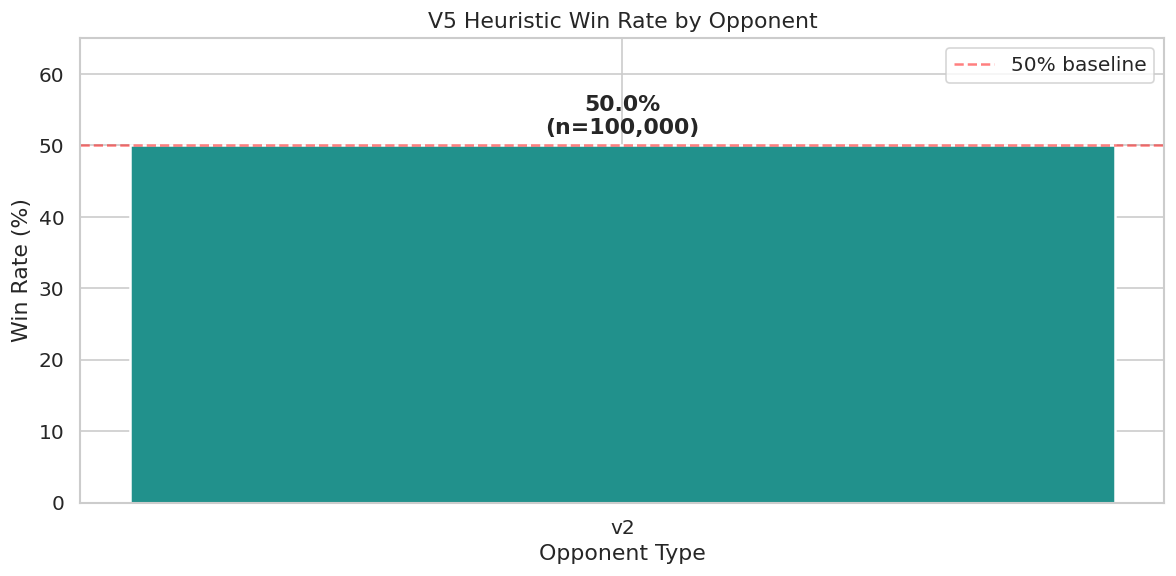

In [32]:
# Win rate per opponent type
wr = df.groupby("opponent_type")["won"].agg(["mean", "count", "sum"])
wr.columns = ["win_rate", "total_games", "wins"]
wr["losses"] = wr["total_games"] - wr["wins"]
wr["win_rate_pct"] = (wr["win_rate"] * 100).round(2)
wr = wr.sort_values("win_rate_pct", ascending=False)
print(wr.to_string())
print()

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("viridis", len(wr))
bars = ax.bar(wr.index, wr["win_rate_pct"], color=colors, edgecolor="white", linewidth=1.5)

# Add value labels
for bar, pct, n in zip(bars, wr["win_rate_pct"], wr["total_games"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{pct:.1f}%\n(n={n:,})", ha="center", va="bottom", fontweight="bold")

ax.axhline(y=50, color="red", linestyle="--", alpha=0.5, label="50% baseline")
ax.set_ylabel("Win Rate (%)")
ax.set_xlabel("Opponent Type")
ax.set_title("V5 Heuristic Win Rate by Opponent")
ax.set_ylim(0, max(wr["win_rate_pct"]) + 15)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Game Length Distribution

/tmp/ipykernel_25119/1625156853.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="opponent_type", y="turns", ax=axes[1], palette="viridis")


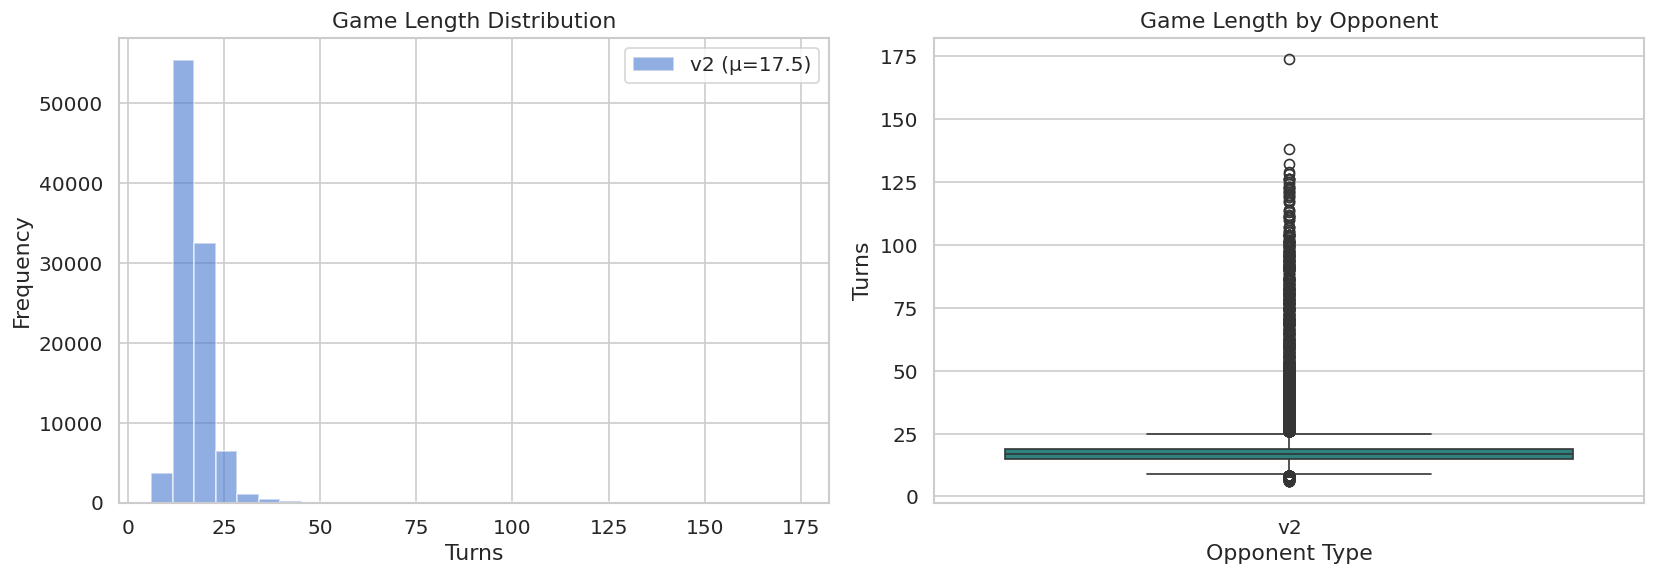

                  count  mean  std  min   25%   50%   75%    max
opponent_type                                                   
v2             100000.0  17.5  5.9  6.0  15.0  17.0  19.0  174.0


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by opponent
for opp_type in df["opponent_type"].unique():
    subset = df[df["opponent_type"] == opp_type]
    axes[0].hist(subset["turns"], bins=30, alpha=0.6, label=f"{opp_type} (μ={subset['turns'].mean():.1f})")

axes[0].set_xlabel("Turns")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Game Length Distribution")
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x="opponent_type", y="turns", ax=axes[1], palette="viridis")
axes[1].set_title("Game Length by Opponent")
axes[1].set_xlabel("Opponent Type")
axes[1].set_ylabel("Turns")

plt.tight_layout()
plt.show()

# Stats table
turn_stats = df.groupby("opponent_type")["turns"].describe().round(1)
print(turn_stats)

## 4. Game Length: Wins vs Losses

/tmp/ipykernel_25119/623345207.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x="outcome", y="turns", ax=ax, palette={"Win": "#2ecc71", "Loss": "#e74c3c"}, inner="quartile")


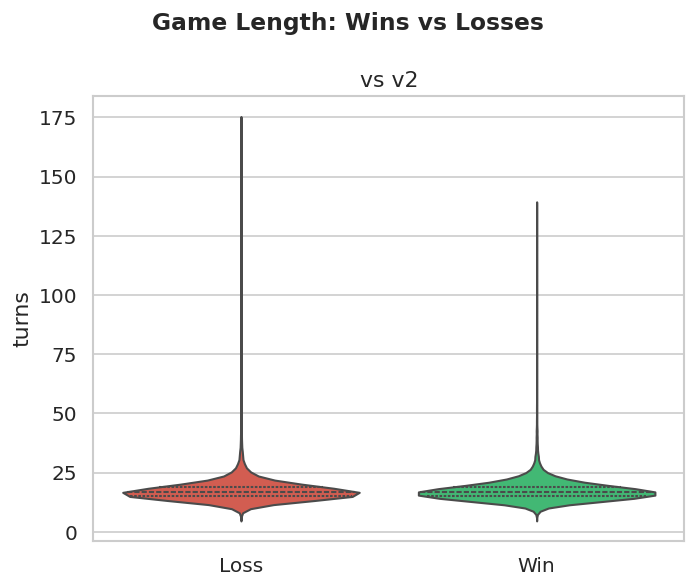

In [34]:
df["outcome"] = df["won"].map({1: "Win", 0: "Loss"})

fig, axes = plt.subplots(1, len(df["opponent_type"].unique()), figsize=(6 * len(df["opponent_type"].unique()), 5))
if len(df["opponent_type"].unique()) == 1:
    axes = [axes]

for ax, opp in zip(axes, df["opponent_type"].unique()):
    subset = df[df["opponent_type"] == opp]
    sns.violinplot(data=subset, x="outcome", y="turns", ax=ax, palette={"Win": "#2ecc71", "Loss": "#e74c3c"}, inner="quartile")
    ax.set_title(f"vs {opp}")
    ax.set_xlabel("")

plt.suptitle("Game Length: Wins vs Losses", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Survivability Analysis

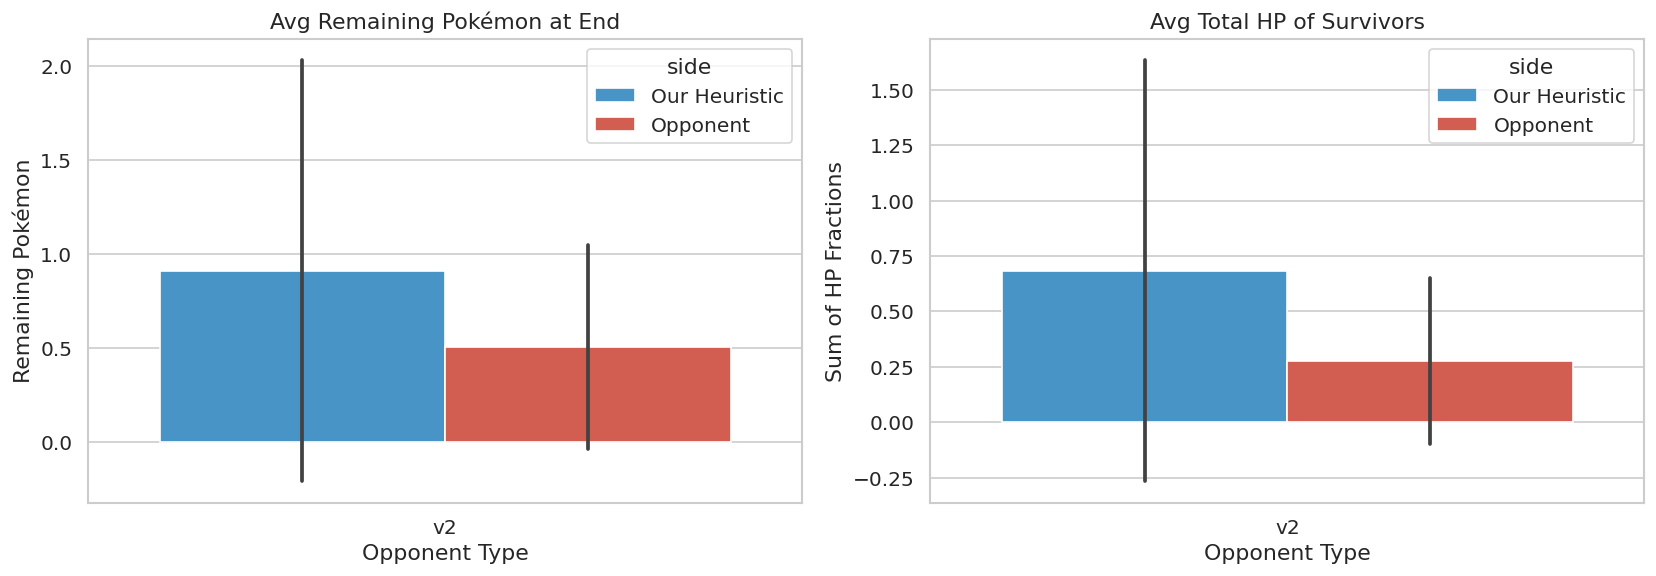

               avg_remaining_us  avg_remaining_opp  avg_fainted_us  \
opponent_type                                                        
v2                         0.91                0.5            5.09   

               avg_fainted_opp  avg_hp_us  avg_hp_opp  
opponent_type                                          
v2                        5.09       0.68        0.28  


In [35]:
# Filter to enriched rows
surv = df.dropna(subset=["remaining_pokemon_us", "remaining_pokemon_opp"]).copy()

if len(surv) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Remaining Pokémon (us vs opponent)
    surv_melted = surv.melt(
        id_vars=["opponent_type", "won"],
        value_vars=["remaining_pokemon_us", "remaining_pokemon_opp"],
        var_name="side",
        value_name="remaining",
    )
    surv_melted["side"] = surv_melted["side"].map(
        {"remaining_pokemon_us": "Our Heuristic", "remaining_pokemon_opp": "Opponent"}
    )

    sns.barplot(data=surv_melted, x="opponent_type", y="remaining", hue="side",
                ax=axes[0], palette=["#3498db", "#e74c3c"], errorbar="sd")
    axes[0].set_title("Avg Remaining Pokémon at End")
    axes[0].set_ylabel("Remaining Pokémon")
    axes[0].set_xlabel("Opponent Type")

    # Remaining HP
    hp_melted = surv.melt(
        id_vars=["opponent_type", "won"],
        value_vars=["total_hp_us", "total_hp_opp"],
        var_name="side",
        value_name="total_hp",
    )
    hp_melted["side"] = hp_melted["side"].map(
        {"total_hp_us": "Our Heuristic", "total_hp_opp": "Opponent"}
    )

    sns.barplot(data=hp_melted, x="opponent_type", y="total_hp", hue="side",
                ax=axes[1], palette=["#3498db", "#e74c3c"], errorbar="sd")
    axes[1].set_title("Avg Total HP of Survivors")
    axes[1].set_ylabel("Sum of HP Fractions")
    axes[1].set_xlabel("Opponent Type")

    plt.tight_layout()
    plt.show()

    # Summary table
    surv_summary = surv.groupby("opponent_type").agg(
        avg_remaining_us=("remaining_pokemon_us", "mean"),
        avg_remaining_opp=("remaining_pokemon_opp", "mean"),
        avg_fainted_us=("fainted_us", "mean"),
        avg_fainted_opp=("fainted_opp", "mean"),
        avg_hp_us=("total_hp_us", "mean"),
        avg_hp_opp=("total_hp_opp", "mean"),
    ).round(2)
    print(surv_summary)
else:
    print("⚠️ No rows with survivability data found.")

## 6. Fainted Pokémon Distribution

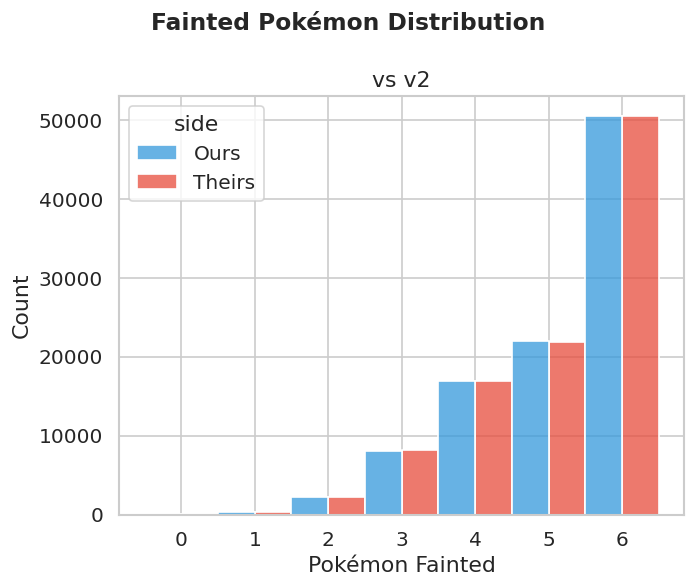

In [36]:
if "fainted_us" in df.columns:
    faint_data = df.dropna(subset=["fainted_us", "fainted_opp"]).copy()

    if len(faint_data) > 0:
        fig, axes = plt.subplots(1, len(faint_data["opponent_type"].unique()),
                                 figsize=(6 * len(faint_data["opponent_type"].unique()), 5))
        if len(faint_data["opponent_type"].unique()) == 1:
            axes = [axes]

        for ax, opp in zip(axes, faint_data["opponent_type"].unique()):
            subset = faint_data[faint_data["opponent_type"] == opp]
            faint_melt = subset.melt(
                value_vars=["fainted_us", "fainted_opp"],
                var_name="side", value_name="fainted",
            )
            faint_melt["side"] = faint_melt["side"].map({"fainted_us": "Ours", "fainted_opp": "Theirs"})
            sns.histplot(data=faint_melt, x="fainted", hue="side", ax=ax,
                         discrete=True, multiple="dodge", palette=["#3498db", "#e74c3c"])
            ax.set_title(f"vs {opp}")
            ax.set_xlabel("Pokémon Fainted")

        plt.suptitle("Fainted Pokémon Distribution", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

## 7. Most Used Moves

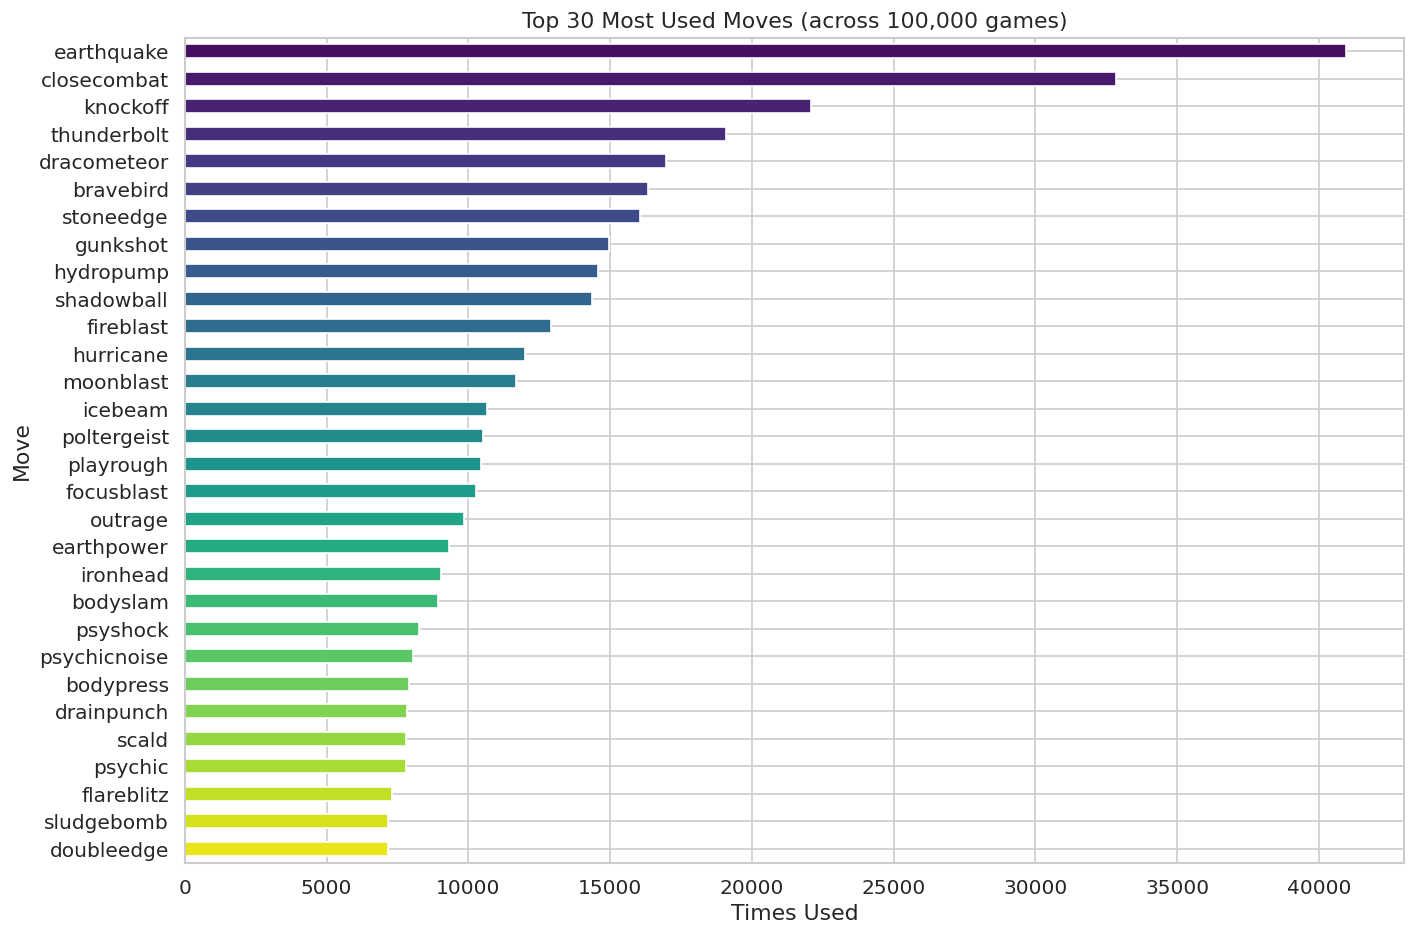


Top 15 moves vs v2 (100,000 games):
moves_used
earthquake     40975
closecombat    32846
knockoff       22106
thunderbolt    19086
dracometeor    16969
bravebird      16330
stoneedge      16073
gunkshot       14953
hydropump      14585
shadowball     14369
fireblast      12908
hurricane      11998
moonblast      11667
icebeam        10646
poltergeist    10531


In [37]:
if "moves_used" in df.columns:
    moves_df = df.dropna(subset=["moves_used"]).copy()

    if len(moves_df) > 0:
        # Explode pipe-separated moves into individual rows
        all_moves = moves_df["moves_used"].str.split("|").explode()
        move_counts = all_moves.value_counts().head(30)

        fig, ax = plt.subplots(figsize=(12, 8))
        colors = sns.color_palette("viridis", len(move_counts))
        move_counts.plot.barh(ax=ax, color=colors)
        ax.set_xlabel("Times Used")
        ax.set_ylabel("Move")
        ax.set_title(f"Top 30 Most Used Moves (across {len(moves_df):,} games)")
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()

        # Moves by opponent type
        for opp in moves_df["opponent_type"].unique():
            subset = moves_df[moves_df["opponent_type"] == opp]
            opp_moves = subset["moves_used"].str.split("|").explode().value_counts().head(15)
            print(f"\nTop 15 moves vs {opp} ({len(subset):,} games):")
            print(opp_moves.to_string())
    else:
        print("No move tracking data available.")

## 8. Most Common Pokémon in Teams

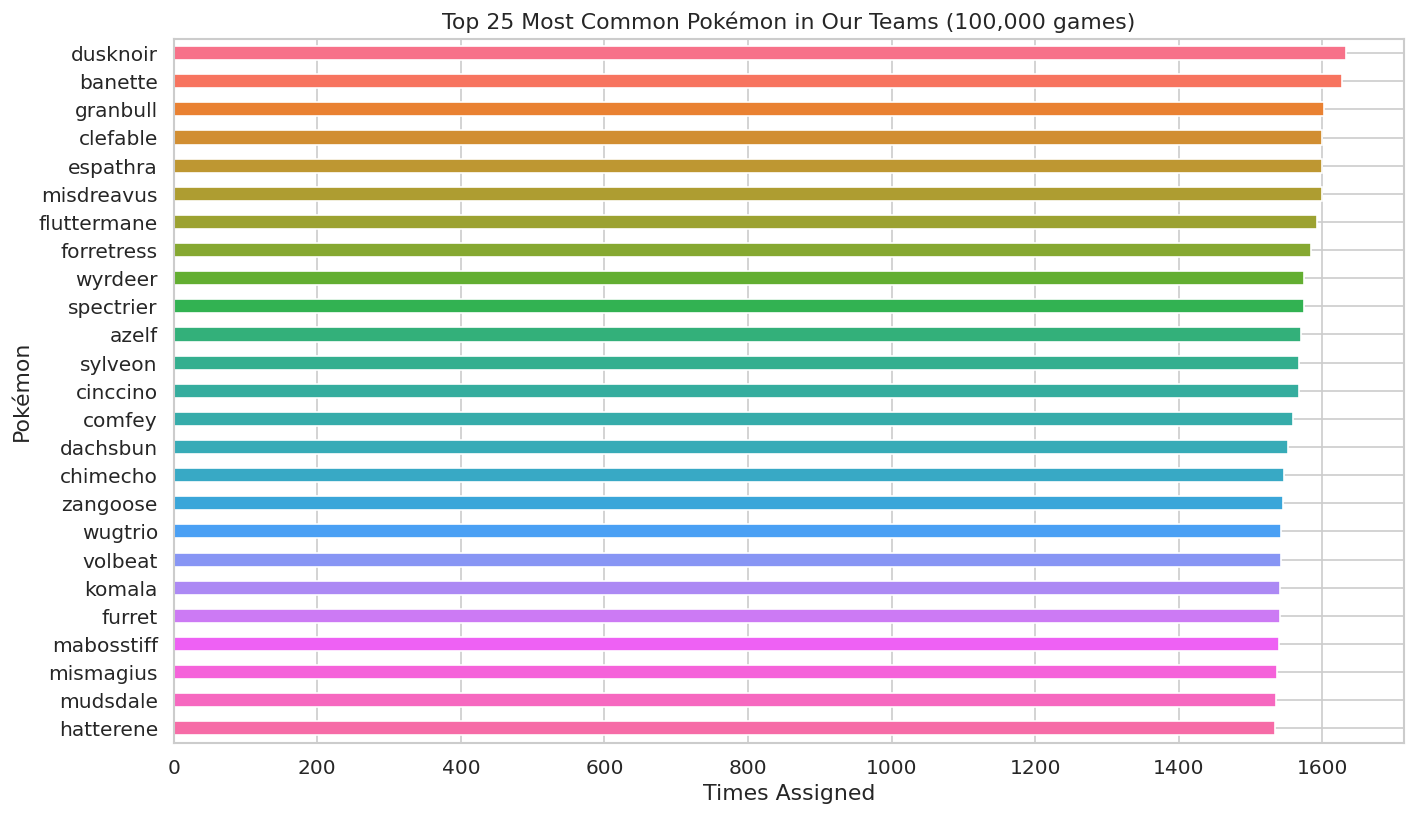

In [38]:
if "team_us" in df.columns:
    team_df = df.dropna(subset=["team_us"]).copy()

    if len(team_df) > 0:
        all_pokemon = team_df["team_us"].str.split("|").explode()
        poke_counts = all_pokemon.value_counts().head(25)

        fig, ax = plt.subplots(figsize=(12, 7))
        colors = sns.color_palette("husl", len(poke_counts))
        poke_counts.plot.barh(ax=ax, color=colors)
        ax.set_xlabel("Times Assigned")
        ax.set_ylabel("Pokémon")
        ax.set_title(f"Top 25 Most Common Pokémon in Our Teams ({len(team_df):,} games)")
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()

## 9. Pokémon Win Rate Analysis

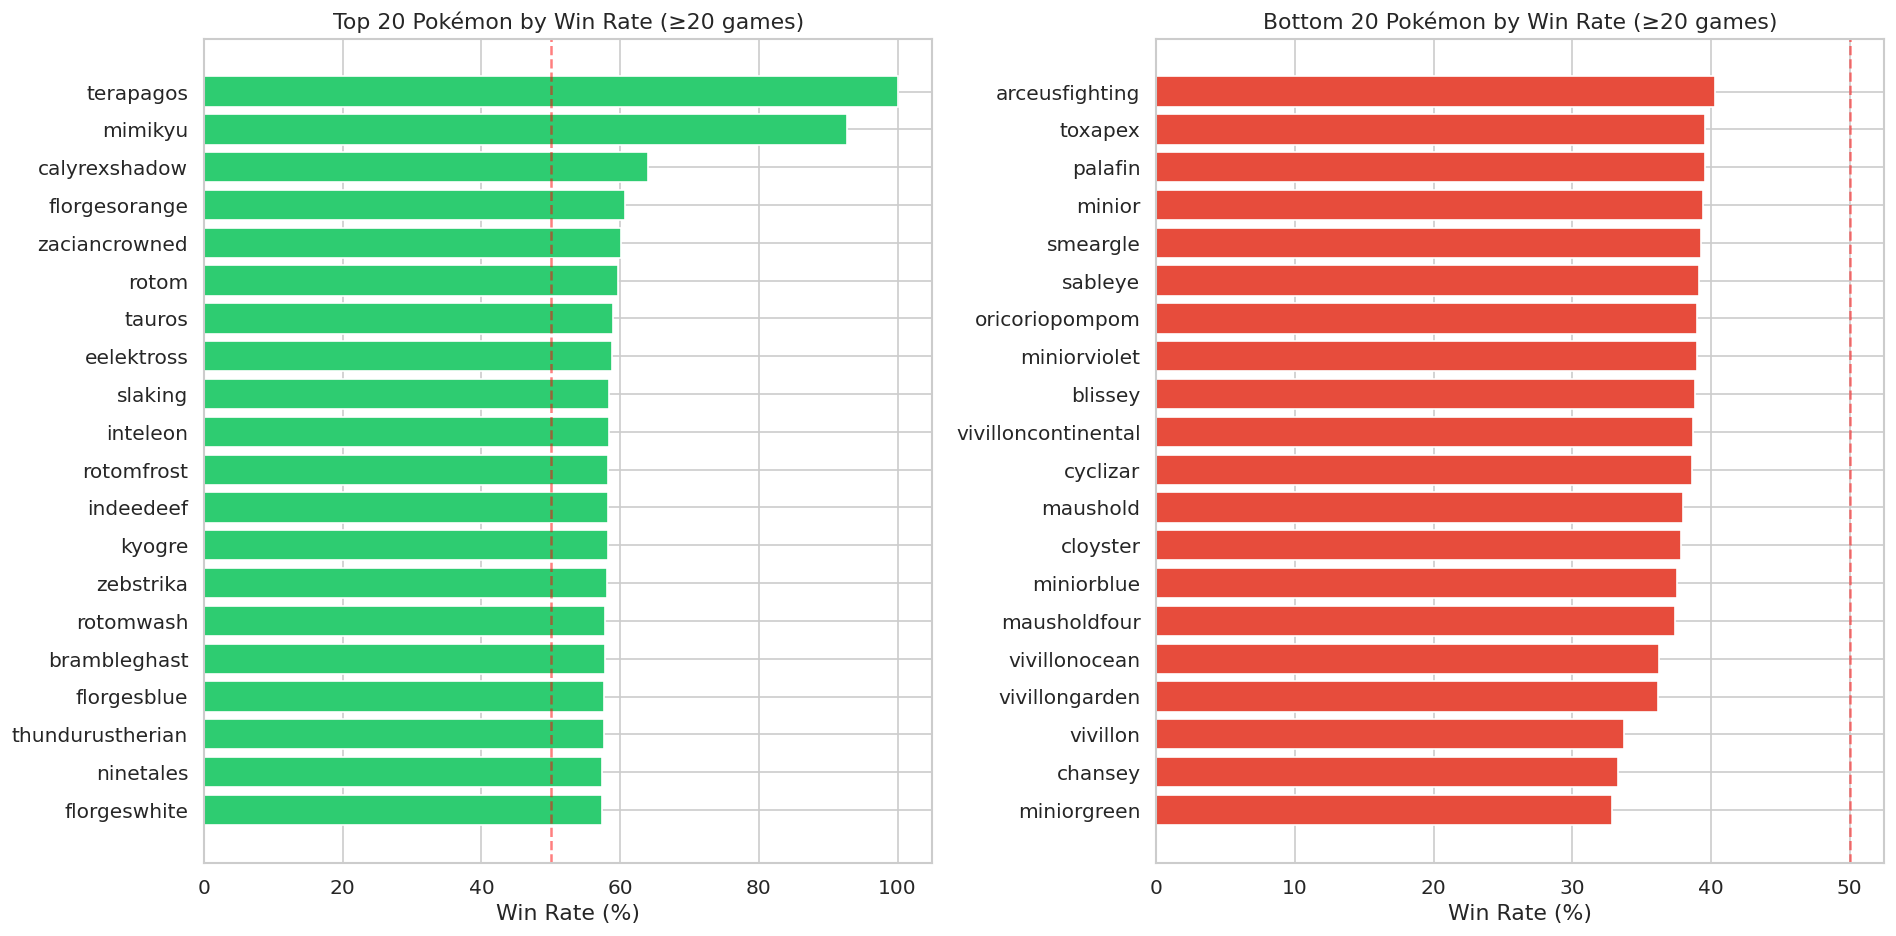


Total unique Pokémon with ≥20 appearances: 564
Overall average win rate: 49.9%


In [39]:
if "team_us" in df.columns:
    team_df = df.dropna(subset=["team_us"]).copy()

    if len(team_df) > 0:
        # Explode teams so each row is one (pokemon, game outcome) pair
        team_exploded = team_df[["team_us", "won"]].copy()
        team_exploded["pokemon"] = team_exploded["team_us"].str.split("|")
        team_exploded = team_exploded.explode("pokemon")

        # Win rate per Pokémon (minimum 20 appearances)
        poke_wr = team_exploded.groupby("pokemon")["won"].agg(["mean", "count"])
        poke_wr.columns = ["win_rate", "appearances"]
        poke_wr = poke_wr[poke_wr["appearances"] >= 20].sort_values("win_rate", ascending=False)

        # Top and bottom performers
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        top20 = poke_wr.head(20)
        axes[0].barh(top20.index, top20["win_rate"] * 100, color="#2ecc71")
        axes[0].set_xlabel("Win Rate (%)")
        axes[0].set_title("Top 20 Pokémon by Win Rate (≥20 games)")
        axes[0].axvline(x=50, color="red", linestyle="--", alpha=0.5)
        axes[0].invert_yaxis()

        bot20 = poke_wr.tail(20)
        axes[1].barh(bot20.index, bot20["win_rate"] * 100, color="#e74c3c")
        axes[1].set_xlabel("Win Rate (%)")
        axes[1].set_title("Bottom 20 Pokémon by Win Rate (≥20 games)")
        axes[1].axvline(x=50, color="red", linestyle="--", alpha=0.5)
        axes[1].invert_yaxis()

        plt.tight_layout()
        plt.show()

        print(f"\nTotal unique Pokémon with ≥20 appearances: {len(poke_wr)}")
        print(f"Overall average win rate: {poke_wr['win_rate'].mean() * 100:.1f}%")

## 10. Win Rate Over Time (Rolling Average)

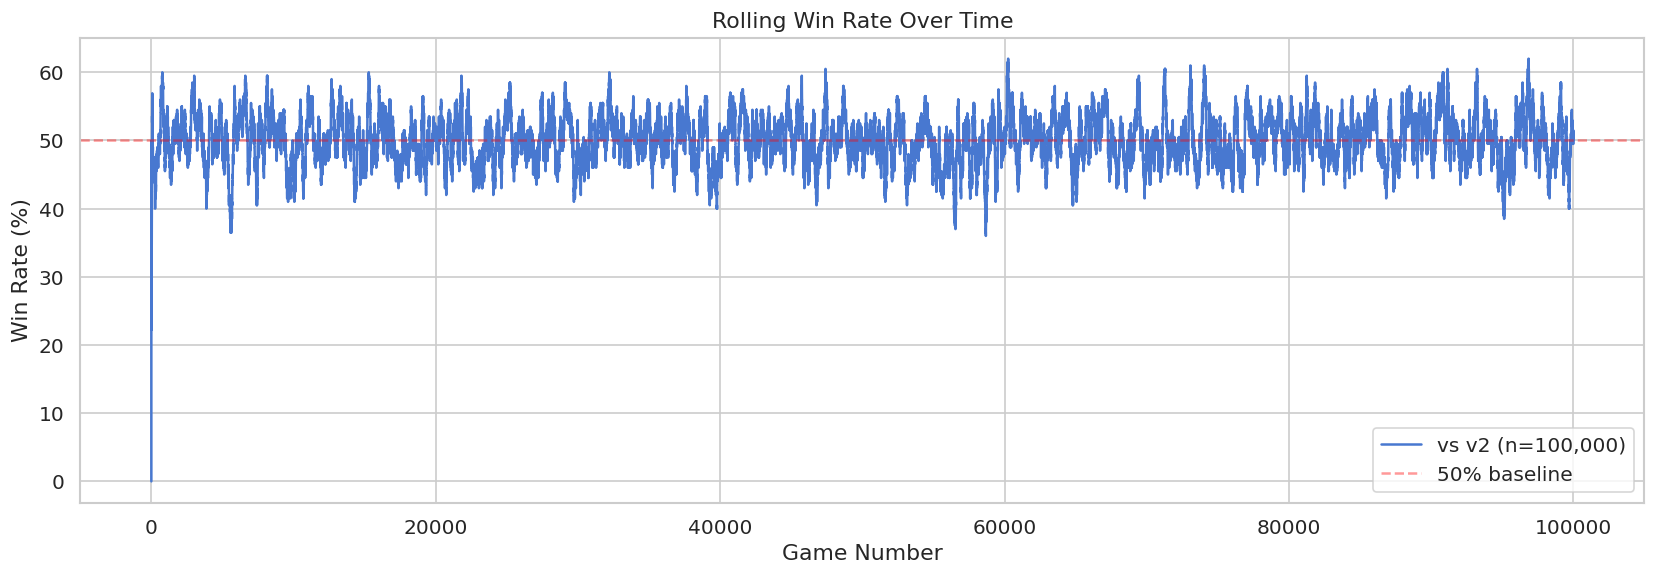

In [40]:
fig, ax = plt.subplots(figsize=(14, 5))

for opp in df["opponent_type"].unique():
    subset = df[df["opponent_type"] == opp].reset_index(drop=True)
    if len(subset) >= 100:
        window = min(200, len(subset) // 5)
        rolling = subset["won"].rolling(window=window, min_periods=1).mean() * 100
        ax.plot(rolling.index, rolling, label=f"vs {opp} (n={len(subset):,})", linewidth=1.5)

ax.axhline(y=50, color="red", linestyle="--", alpha=0.4, label="50% baseline")
ax.set_xlabel("Game Number")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Rolling Win Rate Over Time")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Summary Statistics

In [41]:
summary_cols = ["opponent_type", "won", "turns"]
if "fainted_us" in df.columns:
    summary_cols.extend(["fainted_us", "fainted_opp", "remaining_pokemon_us", "remaining_pokemon_opp", "total_hp_us", "total_hp_opp"])

summary = df[summary_cols].groupby("opponent_type").agg(
    games=("won", "count"),
    wins=("won", "sum"),
    win_rate=("won", "mean"),
    avg_turns=("turns", "mean"),
    median_turns=("turns", "median"),
)

if "fainted_us" in df.columns:
    extra = df.dropna(subset=["fainted_us"]).groupby("opponent_type").agg(
        avg_fainted_us=("fainted_us", "mean"),
        avg_fainted_opp=("fainted_opp", "mean"),
        avg_remaining_us=("remaining_pokemon_us", "mean"),
        avg_remaining_opp=("remaining_pokemon_opp", "mean"),
    )
    summary = summary.join(extra)

summary["win_rate"] = (summary["win_rate"] * 100).round(2)
summary = summary.round(2)

print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(summary.to_string())
print()
print(f"Total games analysed: {len(df):,}")

FINAL SUMMARY
                games   wins  win_rate  avg_turns  median_turns  avg_fainted_us  avg_fainted_opp  avg_remaining_us  avg_remaining_opp
opponent_type                                                                                                                        
v2             100000  50035     50.04       17.5          17.0            5.09             5.09              0.91                0.5

Total games analysed: 100,000
